In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from fishsense_imwut.camera import reconstruct_points
from matplotlib.patches import Ellipse

## Setup of Simulation
The following reasonable defaults that match the systems we tested against.

In [2]:
IMAGE_WIDTH, IMAGE_HEIGHT = 4014, 3016
FOCAL_LENGTH_PX = 2850
LASER_DIAMETER_M = 5.6 * 1e-3  # Convert mm to meters

IMAGE_WIDTH, IMAGE_HEIGHT, FOCAL_LENGTH_PX, LASER_DIAMETER_M

(4014, 3016, 2850, 0.0056)

In [3]:
camera_intrinsics = np.array([
    [FOCAL_LENGTH_PX, 0, IMAGE_WIDTH / 2],
    [0, FOCAL_LENGTH_PX, IMAGE_HEIGHT / 2],
    [0, 0, 1]
])
inverted_camera_intrinsics = np.linalg.inv(camera_intrinsics)

camera_intrinsics, inverted_camera_intrinsics

(array([[2.850e+03, 0.000e+00, 2.007e+03],
        [0.000e+00, 2.850e+03, 1.508e+03],
        [0.000e+00, 0.000e+00, 1.000e+00]]),
 array([[ 3.50877193e-04,  0.00000000e+00, -7.04210526e-01],
        [ 0.00000000e+00,  3.50877193e-04, -5.29122807e-01],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]]))

In [4]:
laser_position = np.array([-0.04, -0.11, 0])
laser_direction = np.array([1e-10, 1e-10, 1])

laser_params = np.concatenate([laser_direction, laser_position[:2]])

laser_position, laser_direction, laser_params

(array([-0.04, -0.11,  0.  ]),
 array([1.e-10, 1.e-10, 1.e+00]),
 array([ 1.0e-10,  1.0e-10,  1.0e+00, -4.0e-02, -1.1e-01]))

## Next we setup data we can use for testing

In [5]:
STEP_COUNT = 1000
t = np.linspace(0.5, 30, STEP_COUNT)

STEP_COUNT, t

(1000,
 array([ 0.5       ,  0.52952953,  0.55905906,  0.58858859,  0.61811812,
         0.64764765,  0.67717718,  0.70670671,  0.73623624,  0.76576577,
         0.7952953 ,  0.82482482,  0.85435435,  0.88388388,  0.91341341,
         0.94294294,  0.97247247,  1.002002  ,  1.03153153,  1.06106106,
         1.09059059,  1.12012012,  1.14964965,  1.17917918,  1.20870871,
         1.23823824,  1.26776777,  1.2972973 ,  1.32682683,  1.35635636,
         1.38588589,  1.41541542,  1.44494494,  1.47447447,  1.504004  ,
         1.53353353,  1.56306306,  1.59259259,  1.62212212,  1.65165165,
         1.68118118,  1.71071071,  1.74024024,  1.76976977,  1.7992993 ,
         1.82882883,  1.85835836,  1.88788789,  1.91741742,  1.94694695,
         1.97647648,  2.00600601,  2.03553554,  2.06506507,  2.09459459,
         2.12412412,  2.15365365,  2.18318318,  2.21271271,  2.24224224,
         2.27177177,  2.3013013 ,  2.33083083,  2.36036036,  2.38988989,
         2.41941942,  2.44894895,  2.4784784

In [6]:
p = laser_position[:, np.newaxis] + t[np.newaxis, :] * laser_direction[:, np.newaxis]

p

array([[-0.04      , -0.04      , -0.04      , ..., -0.04      ,
        -0.04      , -0.04      ],
       [-0.11      , -0.11      , -0.11      , ..., -0.11      ,
        -0.11      , -0.11      ],
       [ 0.5       ,  0.52952953,  0.55905906, ..., 29.94094094,
        29.97047047, 30.        ]], shape=(3, 1000))

In [7]:
s = p / p[2, :]
s = camera_intrinsics @ s

s

array([[1.77900000e+03, 1.79171456e+03, 1.80308594e+03, ...,
        2.00319250e+03, 2.00319626e+03, 2.00320000e+03],
       [8.81000000e+02, 9.15965029e+02, 9.47236348e+02, ...,
        1.49752939e+03, 1.49753970e+03, 1.49755000e+03],
       [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, ...,
        1.00000000e+00, 1.00000000e+00, 1.00000000e+00]], shape=(3, 1000))

In [8]:
s_pixel = np.round(s)

s_pixel

array([[1.779e+03, 1.792e+03, 1.803e+03, ..., 2.003e+03, 2.003e+03,
        2.003e+03],
       [8.810e+02, 9.160e+02, 9.470e+02, ..., 1.498e+03, 1.498e+03,
        1.498e+03],
       [1.000e+00, 1.000e+00, 1.000e+00, ..., 1.000e+00, 1.000e+00,
        1.000e+00]], shape=(3, 1000))

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/chris/Repos/school/e4e/fishsense/imwut-2026-fishsense-lite_python/fishsense_imwut/camera.py:39: RuntimeWarning: divide by zero encountered in divide
  point_constants_noisy = (
/home/chris/Repos/school/e4e/fishsense/imwut-2026-fishsense-lite_python/fishsense_imwut/camera.py:43: RuntimeWarning: invalid value encountered in multiply
  world_points = np.tile(point_constants_noisy, (3, 1)) * final_laser_axis


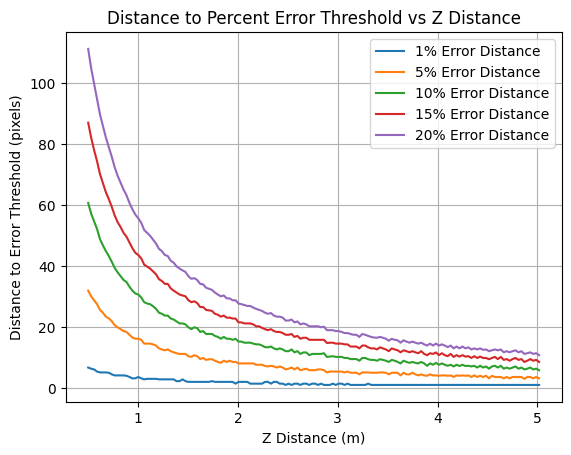

In [9]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

    if p[2, i] > 5:
        break

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

  0%|          | 0/1000 [00:00<?, ?it/s]

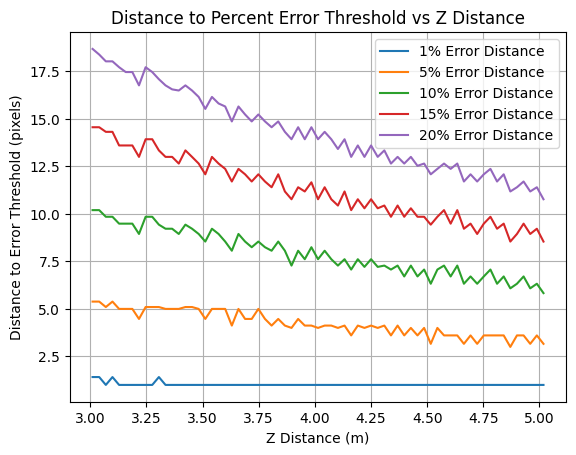

In [10]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    if p[2, i] < 3:
        continue

    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

    if p[2, i] > 5:
        break

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

  0%|          | 0/1000 [00:00<?, ?it/s]

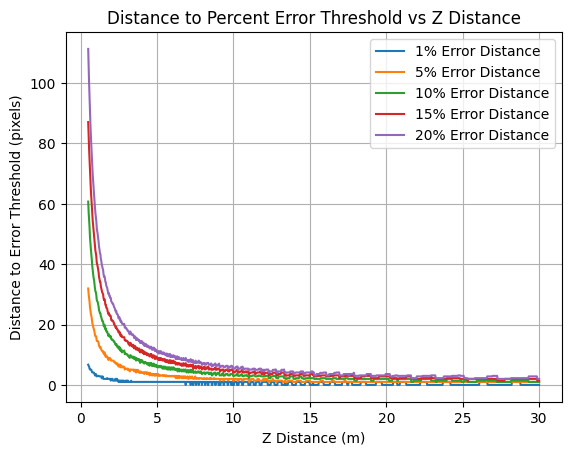

In [11]:
z_values = []
one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for i in tqdm(range(s_pixel.shape[1])):
    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, i]) / p[2, i] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, i], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, i])

one_percent_error_distance, five_percent_error_distance, ten_percent_error_distance, fifteen_percent_error_distance, twenty_percent_error_distance, z_values

plt.plot(z_values, one_percent_error_distance, label='1% Error Distance')
plt.plot(z_values, five_percent_error_distance, label='5% Error Distance')
plt.plot(z_values, ten_percent_error_distance, label='10% Error Distance')
plt.plot(z_values, fifteen_percent_error_distance, label='15% Error Distance')
plt.plot(z_values, twenty_percent_error_distance, label='20% Error Distance')
plt.xlabel('Z Distance (m)')
plt.ylabel('Distance to Error Threshold (pixels)')
plt.title('Distance to Percent Error Threshold vs Z Distance')
plt.legend()
plt.grid()

In [12]:
p_left = p.copy()
p_left[0, :] -= LASER_DIAMETER_M / 2

p_right = p.copy()
p_right[0, :] += LASER_DIAMETER_M / 2

p_up = p.copy()
p_up[1, :] += LASER_DIAMETER_M / 2

p_down = p.copy()
p_down[1, :] -= LASER_DIAMETER_M / 2

p_left[:, 0], p_right[:, 0], p_up[:, 0], p_down[:, 0]

(array([-0.0428, -0.11  ,  0.5   ]),
 array([-0.0372, -0.11  ,  0.5   ]),
 array([-0.04  , -0.1072,  0.5   ]),
 array([-0.04  , -0.1128,  0.5   ]))

In [13]:
s_left = p_left / p_left[2, :]
s_left = camera_intrinsics @ s_left

s_right = p_right / p_right[2, :]
s_right = camera_intrinsics @ s_right

s_up = p_up / p_up[2, :]
s_up = camera_intrinsics @ s_up

s_down = p_down / p_down[2, :]
s_down = camera_intrinsics @ s_down

s_left[:, 0], s_right[:, 0], s_up[:, 0], s_down[:, 0]

(array([1.76304e+03, 8.81000e+02, 1.00000e+00]),
 array([1.79496e+03, 8.81000e+02, 1.00000e+00]),
 array([1.7790e+03, 8.9696e+02, 1.0000e+00]),
 array([1.7790e+03, 8.6504e+02, 1.0000e+00]))

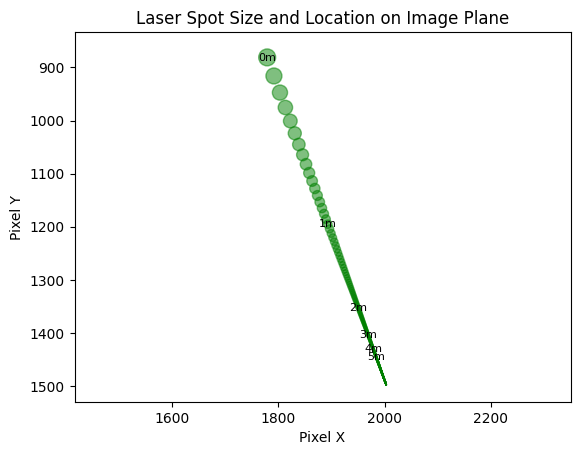

In [25]:
fig, ax = plt.subplots()

prev_z_value_shown = -1
for idx in range(s.shape[1]):
    center_x = s[0, idx]
    center_y = s[1, idx]

    width = s_right[0, idx] - s_left[0, idx]
    height = s_up[1, idx] - s_down[1, idx]

    z_value = int(p[2, idx])
    if z_value != prev_z_value_shown and z_value < 6:
        ax.text(center_x, center_y, f'{z_value}m', color='black', fontsize=8, ha='center', va='center')
        prev_z_value_shown = z_value

    ellipse = Ellipse((center_x, center_y), width, height, edgecolor='g', facecolor='g', alpha=0.5)
    ax.add_patch(ellipse)

ax.set_aspect('equal', adjustable='datalim') # Adjusts the aspect ratio of the plot
ax.autoscale() # Adjusts axis limits to fully contain the patch
ax.set_xlabel('Pixel X')
ax.set_ylabel('Pixel Y')
ax.set_title('Laser Spot Size and Location on Image Plane')
plt.gca().invert_yaxis()

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/chris/Repos/school/e4e/fishsense/imwut-2026-fishsense-lite_python/fishsense_imwut/camera.py:39: RuntimeWarning: divide by zero encountered in divide
  point_constants_noisy = (
/home/chris/Repos/school/e4e/fishsense/imwut-2026-fishsense-lite_python/fishsense_imwut/camera.py:43: RuntimeWarning: invalid value encountered in multiply
  world_points = np.tile(point_constants_noisy, (3, 1)) * final_laser_axis


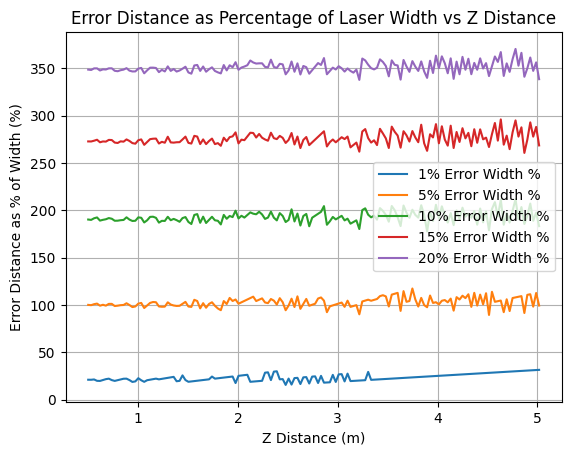

In [26]:
z_values = []
widths = []
heights = []

one_percent_error_distance = []
five_percent_error_distance = []
ten_percent_error_distance = []
fifteen_percent_error_distance = []
twenty_percent_error_distance = []

for idx in tqdm(range(s.shape[1])):
    center_x = s[0, idx]
    center_y = s[1, idx]

    width = s_right[0, idx] - s_left[0, idx]
    height = s_up[1, idx] - s_down[1, idx]

    heat_map = np.zeros((IMAGE_WIDTH, IMAGE_HEIGHT), dtype=float)

    x_range = np.arange(0, IMAGE_WIDTH)
    y_range = np.arange(0, IMAGE_HEIGHT)

    xy_grid = np.array(np.meshgrid(x_range, y_range, indexing='ij'))
    xy_homogeneous = np.vstack((xy_grid.reshape(2, -1), np.ones((1, xy_grid.shape[1] * xy_grid.shape[2]))))

    p_reconstructed, _ = reconstruct_points(xy_homogeneous, inverted_camera_intrinsics, laser_position, laser_direction)
    percent_errors = np.abs(p_reconstructed[2, :] - p[2, idx]) / p[2, idx] * 100
    distances = np.linalg.norm(xy_homogeneous[:2, :] - np.tile(s_pixel[:2, idx], (xy_homogeneous.shape[1], 1)).T, axis=0)

    one_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 1])][0])
    five_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 5])][0])
    ten_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 10])][0])
    fifteen_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 15])][0])
    twenty_percent_error_distance.append(distances[distances == np.min(distances[percent_errors > 20])][0])

    z_values.append(p[2, idx])
    widths.append(width)
    heights.append(height)

    if p[2, idx] > 5:
        break
    
one_percent_error_distance = np.array(one_percent_error_distance)
five_percent_error_distance = np.array(five_percent_error_distance)
ten_percent_error_distance = np.array(ten_percent_error_distance)
fifteen_percent_error_distance = np.array(fifteen_percent_error_distance)
twenty_percent_error_distance = np.array(twenty_percent_error_distance)

z_values = np.array(z_values)
widths = np.array(widths)
heights = np.array(heights)

one_percent_width_percent = one_percent_error_distance / widths * 100
one_percent_height_percent = one_percent_error_distance / heights * 100
five_percent_width_percent = five_percent_error_distance / widths * 100
five_percent_height_percent = five_percent_error_distance / heights * 100
ten_percent_width_percent = ten_percent_error_distance / widths * 100
ten_percent_height_percent = ten_percent_error_distance / heights * 100
fifteen_percent_width_percent = fifteen_percent_error_distance / widths * 100
fifteen_percent_height_percent = fifteen_percent_error_distance / heights * 100
twenty_percent_width_percent = twenty_percent_error_distance / widths * 100
twenty_percent_height_percent = twenty_percent_error_distance / heights * 100

plt.plot(z_values, one_percent_width_percent, label='1% Error Width %')
plt.plot(z_values, five_percent_width_percent, label='5% Error Width %')
plt.plot(z_values, ten_percent_width_percent, label='10% Error Width %')
plt.plot(z_values, fifteen_percent_width_percent, label='15% Error Width %')
plt.plot(z_values, twenty_percent_width_percent, label='20% Error Width %')
plt.xlabel('Z Distance (m)')
plt.ylabel('Error Distance as % of Width (%)')
plt.title('Error Distance as Percentage of Laser Width vs Z Distance')
plt.legend()
plt.grid()